In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_pickle(
    "/home/clement/Documents/Projets/OcularRigidity/manuscript/chapters/analysis/positional_pulsation/preliminary_results.pkl"
)

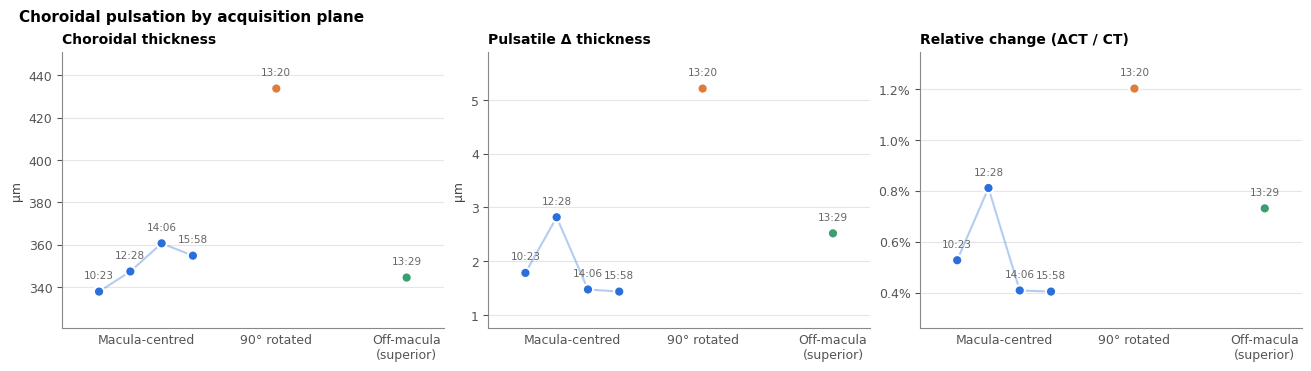

In [27]:
# | label: fig-positional-pulsation-preliminary
# | fig-cap: "Choroidal thickness, pulsatile Δ thickness and relative change for each acquisition plane. Labels give the acquisition time."
# | warning: false
# | echo: false


import numpy as np
from matplotlib.ticker import PercentFormatter

plotted_df = df[df["Type"].notna()].sort_values("acquired_at").reset_index(drop=True)

planes = list(dict.fromkeys(plotted_df["Type"]))  # order of first acquisition
plane_labels = {
    "Macular centered": "Macula-centred",
    "90degrees": "90° rotated",
    "off-macula (Up)": "Off-macula\n(superior)",
}
colors = dict(zip(planes, ["#2a6fdb", "#e07b39", "#3a9e6f", "#8e5bd0"]))

# Spread repeated acquisitions of the same plane horizontally (chronological)
plotted_df["x"] = plotted_df["Type"].map(planes.index).astype(float)
for plane, grp in plotted_df.groupby("Type"):
    if len(grp) > 1:
        plotted_df.loc[grp.index, "x"] += np.linspace(-0.36, 0.36, len(grp))

metrics = [
    ("minCT_um", "Choroidal thickness", "µm"),
    ("deltaCT_um", "Pulsatile Δ thickness", "µm"),
    ("RelativeGrowth", "Relative change (ΔCT / CT)", None),
]

with plt.rc_context(
    {
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.titleweight": "semibold",
        "axes.titlelocation": "left",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#888888",
        "axes.labelcolor": "#444444",
        "xtick.color": "#555555",
        "ytick.color": "#555555",
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.color": "#e6e6e6",
        "grid.linewidth": 0.8,
    }
):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True, layout="constrained")

    for ax, (col, title, unit) in zip(axes, metrics):
        # Faint line linking repeated acquisitions of the same plane (same day)
        for plane, grp in plotted_df.groupby("Type"):
            if len(grp) > 1:
                ax.plot(
                    grp["x"],
                    grp[col],
                    color=colors[plane],
                    lw=1.5,
                    alpha=0.35,
                    zorder=1,
                )
        ax.scatter(
            plotted_df["x"],
            plotted_df[col],
            c=plotted_df["Type"].map(colors),
            s=55,
            edgecolor="white",
            linewidth=1.5,
            zorder=3,
        )
        # Acquisition time above each point
        for _, row in plotted_df.iterrows():
            ax.annotate(
                row["acquired_at"].strftime("%H:%M"),
                (row["x"], row[col]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                va="bottom",
                fontsize=7.5,
                color="#666666",
            )

        ax.set_title(title)
        if unit:
            ax.set_ylabel(unit)
        else:
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
        ax.margins(x=0.12, y=0.18)
        ax.set_xticks(range(len(planes)))
        ax.set_xticklabels([plane_labels.get(p, p) for p in planes])
        ax.tick_params(axis="x", length=0)
        ax.set_axisbelow(True)

    fig.suptitle(
        "Choroidal pulsation by acquisition plane",
        x=0.01,
        ha="left",
        fontsize=11,
        fontweight="bold",
    )
    plt.show()
